Step 1 — Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Step 2 — Load Data (30 Features)

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

Step 3 — Standardize (VERY Important for SVM)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Reduce to 2D using PCA (for visualization only)

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Step 5 — Train SVM (RBF Kernel)

In [5]:
model = SVC(kernel='rbf', C=10, gamma=0.5)
model.fit(X_pca, y)

,C,10
,kernel,'rbf'
,degree,3
,gamma,0.5
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Step 6 — Contour Plotting (Decision Boundary)

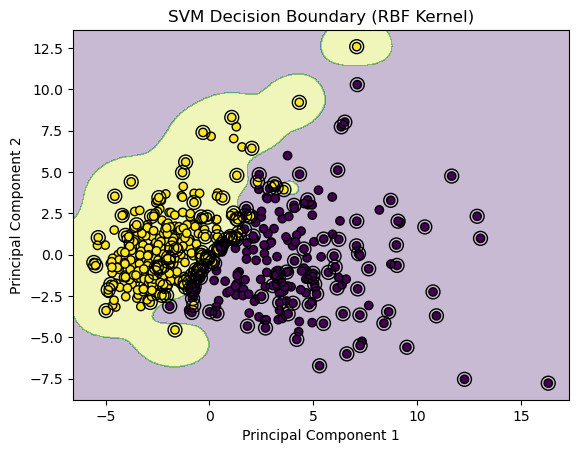

In [6]:
# Create mesh grid
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict on grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contour
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k')

# Highlight support vectors
plt.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='k')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("SVM Decision Boundary (RBF Kernel)")
plt.show()


Now change to 3D from 30D -> 2D

oreviously from 30D -> 2D

Step 1 — Import Libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from mpl_toolkits.mplot3d import Axes3D


Step 2 — Load & Standardize

In [8]:
data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Step 3 — Reduce to 3D (PCA)

In [9]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

Step 4 — Train Linear SVM

In [10]:
model = SVC(kernel='linear', C=1)
model.fit(X_pca, y)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Step 5 — Extract Hyperplane Equation

In [11]:
w = model.coef_[0]
b = model.intercept_[0]

Step 6 — Create 3D Plot

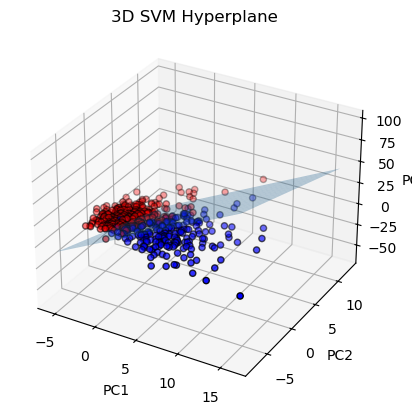

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter data
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
           c=y, cmap='bwr', edgecolor='k')

# Create grid for plane
xx, yy = np.meshgrid(
    np.linspace(X_pca[:,0].min(), X_pca[:,0].max(), 20),
    np.linspace(X_pca[:,1].min(), X_pca[:,1].max(), 20)
)

# Solve for z
zz = -(w[0]*xx + w[1]*yy + b) / w[2]

ax.plot_surface(xx, yy, zz, alpha=0.3)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D SVM Hyperplane")

plt.show()


In [13]:
xx, yy = np.meshgrid(
    np.linspace(X_pca[:,0].min(), X_pca[:,0].max(), 20),
    np.linspace(X_pca[:,1].min(), X_pca[:,1].max(), 20)
)

zz = -(w[0]*xx + w[1]*yy + b) / w[2]

In [14]:
import plotly.graph_objects as go

In [15]:
fig = go.Figure()

# Scatter points
fig.add_trace(go.Scatter3d(
    x=X_pca[:,0],
    y=X_pca[:,1],
    z=X_pca[:,2],
    mode='markers',
    marker=dict(
        size=5,
        color=y,
        colorscale='RdBu',
        opacity=0.8
    ),
    name='Data Points'
))

# Hyperplane surface
fig.add_trace(go.Surface(
    x=xx,
    y=yy,
    z=zz,
    opacity=0.4,
    showscale=False,
    name='Hyperplane'
))

fig.update_layout(
    title="3D SVM Hyperplane (Plotly)",
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    )
)

fig.show()
